## Self-Pruning MLP for CIFAR-10

This notebook implements a self-pruning Multilayer Perceptron (MLP) for image classification on the CIFAR-10 dataset. The core idea is to introduce learnable 'gates' for each weight in the linear layers, allowing the network to automatically prune connections during training by driving gate values towards zero. A sparsity loss encourages this pruning behavior.

### 1. Setup & Hyperparameters

This section imports necessary libraries and defines global hyperparameters for training, such as the number of epochs, batch size, learning rate, sparsity regularization strengths (lambdas), and the pruning threshold. It also sets up the device (GPU if available, otherwise CPU) and a seed for reproducibility.

In [26]:
import os
import random
from dataclasses import dataclass
from typing import List

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

EPOCHS       = 15
BATCH_SIZE   = 128
LR           = 1e-3

LAMBDAS = [3e-5, 5e-5, 8e-5]

PRUNE_THRESH = 1e-2
OUT_DIR      = "./outputs"
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def set_seed(seed: int = 42) -> None:
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


Using device: cpu


### 2. PrunableLinear Layer

This custom `PrunableLinear` layer is the core component for self-pruning. It extends `nn.Linear` by adding `gate_scores` for each weight. During the forward pass, these gate scores are passed through a sigmoid function to produce 'gates' (values between 0 and 1), which then element-wise multiply the standard weights. This allows the network to learn which connections are important by adjusting the gate scores.

In [27]:
class PrunableLinear(nn.Module):


    def __init__(self, in_features: int, out_features: int) -> None:
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features


        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias   = nn.Parameter(torch.empty(out_features))


        self.gate_scores = nn.Parameter(torch.empty(out_features, in_features))

        self._reset_parameters()

    def _reset_parameters(self) -> None:

        nn.init.kaiming_uniform_(self.weight, a=5 ** 0.5)
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
        bound = 1.0 / (fan_in ** 0.5) if fan_in > 0 else 0.0
        nn.init.uniform_(self.bias, -bound, bound)


        nn.init.normal_(self.gate_scores, mean=0.0, std=0.1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gates          = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    @torch.no_grad()
    def gates(self) -> torch.Tensor:

        return torch.sigmoid(self.gate_scores).detach()

    def extra_repr(self) -> str:
        return f'in_features={self.in_features}, out_features={self.out_features}'


### 3. Network Architecture

The `SelfPruningMLP` defines a simple Multilayer Perceptron using the `PrunableLinear` layers. It flattens the input image and then passes it through three `PrunableLinear` layers with ReLU activations in between, followed by a final output layer for classification.

In [28]:
class SelfPruningMLP(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = PrunableLinear(3 * 32 * 32, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


### 4. Sparsity Loss & Data Loaders

This section defines two utility functions:
*   `sparsity_loss`: Calculates the L1 norm of all (sigmoid-transformed) gate values across the network. This loss term is added to the classification loss to encourage gates to become small, leading to pruning.
*   `get_loaders`: Prepares and loads the CIFAR-10 dataset with appropriate transformations (random cropping, horizontal flips, normalization) for training and testing, returning PyTorch DataLoaders.

In [29]:
def sparsity_loss(model: nn.Module) -> torch.Tensor:

    device = next(model.parameters()).device
    total = torch.zeros((), device=device)
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            total = total + torch.sigmoid(module.gate_scores).sum()
    return total

def get_loaders(batch_size: int, data_root: str = './data'):
    normalize = transforms.Normalize(
        (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
    )
    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize,
    ])
    test_tf = transforms.Compose([transforms.ToTensor(), normalize])

    trainset = torchvision.datasets.CIFAR10(root=data_root, train=True,  download=True, transform=train_tf)
    testset  = torchvision.datasets.CIFAR10(root=data_root, train=False, download=True, transform=test_tf)

    train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(testset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader


### 5. Training Loop & Evaluators

This section contains the core training and evaluation logic:
*   `RunResult`: A dataclass to store the results of each training run.
*   `evaluate`: Calculates the test accuracy of the model.
*   `collect_gates`: Gathers all gate values from the `PrunableLinear` layers.
*   `sparsity_percent`: Calculates the percentage of gates below a given threshold.
*   `train_one_run`: Orchestrates the training process for a single lambda value, including optimizer setup (with separate learning rates for base weights and gate scores) and the combined loss calculation (classification loss + sparsity loss). It prints progress during training and returns a `RunResult`.

In [30]:
@dataclass
class RunResult:
    lam: float
    test_acc: float
    sparsity: float
    gates: np.ndarray

def evaluate(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(dim=1)
            correct += (pred == y).sum().item()
            total   += y.size(0)
    return 100.0 * correct / total

def collect_gates(model: nn.Module) -> np.ndarray:
    buckets: List[np.ndarray] = []
    for m in model.modules():
        if isinstance(m, PrunableLinear):
            buckets.append(m.gates().cpu().numpy().ravel())
    return np.concatenate(buckets)

def sparsity_percent(gates: np.ndarray, threshold: float = PRUNE_THRESH) -> float:
    return 100.0 * float((gates < threshold).sum()) / float(gates.size)

def train_one_run(lam: float, epochs: int, batch_size: int, lr: float, device: torch.device) -> RunResult:
    set_seed(42)
    train_loader, test_loader = get_loaders(batch_size)

    model = SelfPruningMLP().to(device)
    ce_loss_fn = nn.CrossEntropyLoss()


    gate_params = []
    base_params = []
    for name, param in model.named_parameters():
        if 'gate_scores' in name:
            gate_params.append(param)
        else:
            base_params.append(param)

    optimizer = optim.Adam([
    {'params': base_params, 'lr': lr, 'weight_decay': 1e-4},
    {'params': gate_params, 'lr': lr * 5, 'weight_decay': 0.0}
    ])

    print(f'\n=== Training with λ = {lam:g} ===')
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, n_correct, n_total = 0.0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits   = model(x)
            cls_loss = ce_loss_fn(logits, y)
            sp_loss  = sparsity_loss(model)

            if epoch<3:
              loss=cls_loss
            else:
              loss = cls_loss + (lam * sp_loss)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * y.size(0)
            n_correct    += (logits.argmax(dim=1) == y).sum().item()
            n_total      += y.size(0)

        g = collect_gates(model)
        print(f'  epoch {epoch:2d} | loss={running_loss/n_total:.4f} | '
              f'train_acc={100*n_correct/n_total:5.2f}% | '
              f'sparsity={sparsity_percent(g):5.2f}%')

    test_acc = evaluate(model, test_loader, device)
    gates    = collect_gates(model)
    return RunResult(lam=lam, test_acc=test_acc, sparsity=sparsity_percent(gates), gates=gates)


### 6. Execution & Visualization

This final section executes the training process for each lambda value defined in `LAMBDAS`. It collects the results, generates a summary table of test accuracy and sparsity for each run, and then creates a histogram of gate values for the best-performing model (based on a combined metric of accuracy and sparsity). The results table is saved to a CSV file, and the plot is saved to a PNG image.


=== Training with λ = 3e-05 ===
  epoch  1 | loss=1.7945 | train_acc=35.21% | sparsity= 0.00%
  epoch  2 | loss=1.6178 | train_acc=42.03% | sparsity= 0.00%
  epoch  3 | loss=11.5011 | train_acc=45.36% | sparsity= 0.00%
  epoch  4 | loss=4.7958 | train_acc=46.23% | sparsity= 0.00%
  epoch  5 | loss=3.4466 | train_acc=47.38% | sparsity= 0.73%
  epoch  6 | loss=2.8443 | train_acc=47.74% | sparsity=44.67%
  epoch  7 | loss=2.4950 | train_acc=48.28% | sparsity=69.12%
  epoch  8 | loss=2.2720 | train_acc=48.80% | sparsity=78.79%
  epoch  9 | loss=2.1138 | train_acc=49.12% | sparsity=83.79%
  epoch 10 | loss=1.9951 | train_acc=49.75% | sparsity=86.92%
  epoch 11 | loss=1.9134 | train_acc=49.81% | sparsity=89.09%
  epoch 12 | loss=1.8421 | train_acc=50.49% | sparsity=90.70%
  epoch 13 | loss=1.7888 | train_acc=50.50% | sparsity=91.96%
  epoch 14 | loss=1.7424 | train_acc=50.48% | sparsity=92.94%
  epoch 15 | loss=1.7054 | train_acc=50.90% | sparsity=93.71%
  -> Final Test Accuracy: 53.52% | F

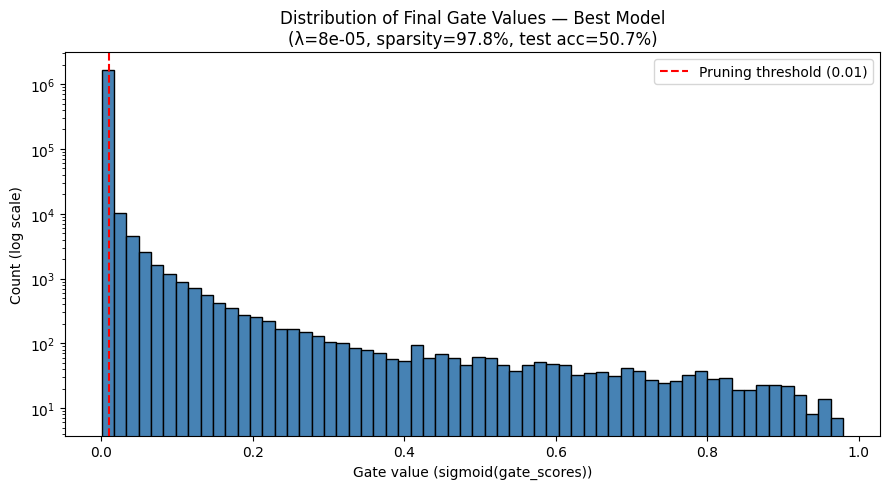


Plot saved to → ./outputs/gate_distribution.png


In [31]:
if __name__ == "__main__":
    results: List[RunResult] = []
    for lam in LAMBDAS:
        res = train_one_run(lam=lam, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, device=device)
        results.append(res)


        print(f"  -> Final Test Accuracy: {res.test_acc:.2f}% | Final Sparsity: {res.sparsity:.2f}%")


    df = pd.DataFrame(
        [(f'{r.lam:g}', round(r.test_acc, 2), round(r.sparsity, 2)) for r in results],
        columns=['Lambda (λ)', 'Test Accuracy (%)', 'Sparsity Level (%)'],
    )
    df.to_csv(os.path.join(OUT_DIR, 'results.csv'), index=False)
    print("\n--- Summary Table ---")
    print(df.to_string(index=False))


    best = max(results, key=lambda r: r.test_acc + r.sparsity)

    plt.figure(figsize=(9, 5))
    plt.hist(best.gates, bins=60, color='steelblue', edgecolor='black')
    plt.axvline(PRUNE_THRESH, linestyle='--', color='red', label=f'Pruning threshold ({PRUNE_THRESH:g})')
    plt.yscale('log')
    plt.xlabel('Gate value (sigmoid(gate_scores))')
    plt.ylabel('Count (log scale)')
    plt.title(f'Distribution of Final Gate Values — Best Model\n(λ={best.lam:g}, sparsity={best.sparsity:.1f}%, test acc={best.test_acc:.1f}%)')
    plt.legend()
    plt.tight_layout()

    plot_path = os.path.join(OUT_DIR, 'gate_distribution.png')
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f'\nPlot saved to → {plot_path}')


Starting extended sweep with LAMBDAS = [1e-06, 1e-05, 0.0001]...

=== Training with λ = 1e-06 ===


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  epoch  1 | loss=1.7945 | train_acc=35.21% | sparsity= 0.00%
  epoch  2 | loss=1.6178 | train_acc=42.03% | sparsity= 0.00%
  epoch  3 | loss=2.2659 | train_acc=44.88% | sparsity= 0.00%
  epoch  4 | loss=2.0623 | train_acc=46.82% | sparsity= 0.00%
  epoch  5 | loss=1.9306 | train_acc=48.47% | sparsity= 0.00%
  epoch  6 | loss=1.8324 | train_acc=49.63% | sparsity= 0.00%
  epoch  7 | loss=1.7535 | train_acc=50.56% | sparsity= 0.28%
  epoch  8 | loss=1.6928 | train_acc=51.62% | sparsity= 0.64%
  epoch  9 | loss=1.6385 | train_acc=52.38% | sparsity= 1.59%
  epoch 10 | loss=1.5935 | train_acc=53.19% | sparsity= 3.36%
  epoch 11 | loss=1.5629 | train_acc=53.49% | sparsity= 5.98%
  epoch 12 | loss=1.5276 | train_acc=53.91% | sparsity= 9.24%
  epoch 13 | loss=1.5003 | train_acc=54.65% | sparsity=12.89%
  epoch 14 | loss=1.4720 | train_acc=55.00% | sparsity=16.75%
  epoch 15 | loss=1.4510 | train_acc=55.31% | sparsity=20.65%
  -> Final Test Accuracy: 54.94% | Final Sparsity: 20.65%

=== Trainin

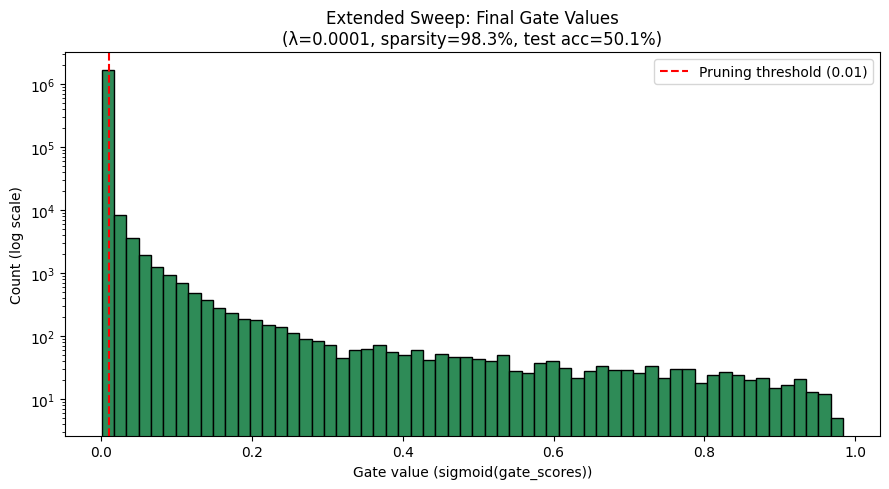


New plot safely saved to → ./outputs/gate_distribution_extended.png


In [32]:

import pandas as pd
import matplotlib.pyplot as plt
import os


NEW_LAMBDAS = [1e-6, 1e-5, 1e-4]
print(f"Starting extended sweep with LAMBDAS = {NEW_LAMBDAS}...")


new_results = []
for lam in NEW_LAMBDAS:
    res = train_one_run(lam=lam, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, device=device)
    new_results.append(res)
    print(f"  -> Final Test Accuracy: {res.test_acc:.2f}% | Final Sparsity: {res.sparsity:.2f}%")


df_new = pd.DataFrame(
    [(f'{r.lam:g}', round(r.test_acc, 2), round(r.sparsity, 2)) for r in new_results],
    columns=['Lambda (λ)', 'Test Accuracy (%)', 'Sparsity Level (%)'],
)
df_new.to_csv(os.path.join(OUT_DIR, 'results_extended.csv'), index=False)
print("\n--- Extended Summary Table ---")
print(df_new.to_string(index=False))


best_new = max(new_results, key=lambda r: r.test_acc + r.sparsity)

plt.figure(figsize=(9, 5))

plt.hist(best_new.gates, bins=60, color='seagreen', edgecolor='black')
plt.axvline(PRUNE_THRESH, linestyle='--', color='red', label=f'Pruning threshold ({PRUNE_THRESH:g})')
plt.yscale('log')
plt.xlabel('Gate value (sigmoid(gate_scores))')
plt.ylabel('Count (log scale)')
plt.title(f'Extended Sweep: Final Gate Values\n(λ={best_new.lam:g}, sparsity={best_new.sparsity:.1f}%, test acc={best_new.test_acc:.1f}%)')
plt.legend()
plt.tight_layout()

new_plot_path = os.path.join(OUT_DIR, 'gate_distribution_extended.png')
plt.savefig(new_plot_path, dpi=150)
plt.show()
print(f'\nNew plot safely saved to → {new_plot_path}')